# Exploración de PCI Histórico Limpio 2005
Este notebook realiza una exploración de datos del archivo `PCI-histo-cleaned-2005.csv`, replicando el flujo de análisis del notebook histórico original.

## 1. Importar librerías

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 2. Cargar datos

In [61]:
file_path = r'../CSVS/PCI-histo-cleaned-2005.csv'
print(f'Cargando archivo: {file_path}')
df = pd.read_csv(file_path)
print('✓ Archivo cargado correctamente')
print(f'Forma del dataset: {df.shape}')
print(f'Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')
df.head()

Cargando archivo: ../CSVS/PCI-histo-cleaned-2005.csv
✓ Archivo cargado correctamente
Forma del dataset: (203268, 10)
Tamaño en memoria: 56.10 MB


,CNN,PCI_Score,Previous_PCI,PCI_Change,Street_Name,PCI_Change_Date,Treatment_or_Survey,Functional_Class,Latitude,Longitude
0,100000,100.0,100.0,0.0,01st st,2005-11-16 16:50:05,Survey,Arterial,37.790794,-122.398869
1,100000,100.0,100.0,0.0,01st st,2007-07-26 16:21:27,Survey,Arterial,37.790794,-122.398869
2,100000,93.0,100.0,-7.0,01st st,2009-08-10 15:43:09,Survey,Arterial,37.790794,-122.398869
3,100000,73.0,93.0,-20.0,01st st,2010-12-23 13:37:35,Survey,Arterial,37.790794,-122.398869
4,100000,56.0,73.0,-17.0,01st st,2013-01-08 15:18:02,Survey,Arterial,37.790794,-122.398869


## 3. Información general del dataset

In [62]:
print('COLUMNAS:')
print(df.columns.tolist())
print('\nTIPOS DE DATOS:')
print(df.dtypes)
print('\nResumen de valores generales:')
print(df.describe(include='all').transpose())

COLUMNAS:
['CNN', 'PCI_Score', 'Previous_PCI', 'PCI_Change', 'Street_Name', 'PCI_Change_Date', 'Treatment_or_Survey', 'Functional_Class', 'Latitude', 'Longitude']

TIPOS DE DATOS:
CNN                      int64
PCI_Score              float64
Previous_PCI           float64
PCI_Change             float64
Street_Name                str
PCI_Change_Date            str
Treatment_or_Survey        str
Functional_Class           str
Latitude               float64
Longitude              float64
dtype: object

Resumen de valores generales:
                        count  unique                  top    freq  \
CNN                  203268.0     NaN                  NaN     NaN   
PCI_Score            203268.0     NaN                  NaN     NaN   
Previous_PCI         203268.0     NaN                  NaN     NaN   
PCI_Change           203268.0     NaN                  NaN     NaN   
Street_Name            203268    4246           geary blvd    2193   
PCI_Change_Date        203268  102413  2008-1

## 4. Valores nulos y calidad de datos

In [63]:
null_analysis = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Porcentaje (%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'Valores Válidos': df.notna().sum().values
})
print(null_analysis.to_string(index=False))
print(f'\nTOTAL de valores nulos: {df.isnull().sum().sum():,}')
print(f'Porcentaje total de nulos: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%')

            Columna  Valores Nulos  Porcentaje (%)  Valores Válidos
                CNN              0             0.0           203268
          PCI_Score              0             0.0           203268
       Previous_PCI              0             0.0           203268
         PCI_Change              0             0.0           203268
        Street_Name              0             0.0           203268
    PCI_Change_Date              0             0.0           203268
Treatment_or_Survey              0             0.0           203268
   Functional_Class              0             0.0           203268
           Latitude              0             0.0           203268
          Longitude              0             0.0           203268

TOTAL de valores nulos: 0
Porcentaje total de nulos: 0.00%


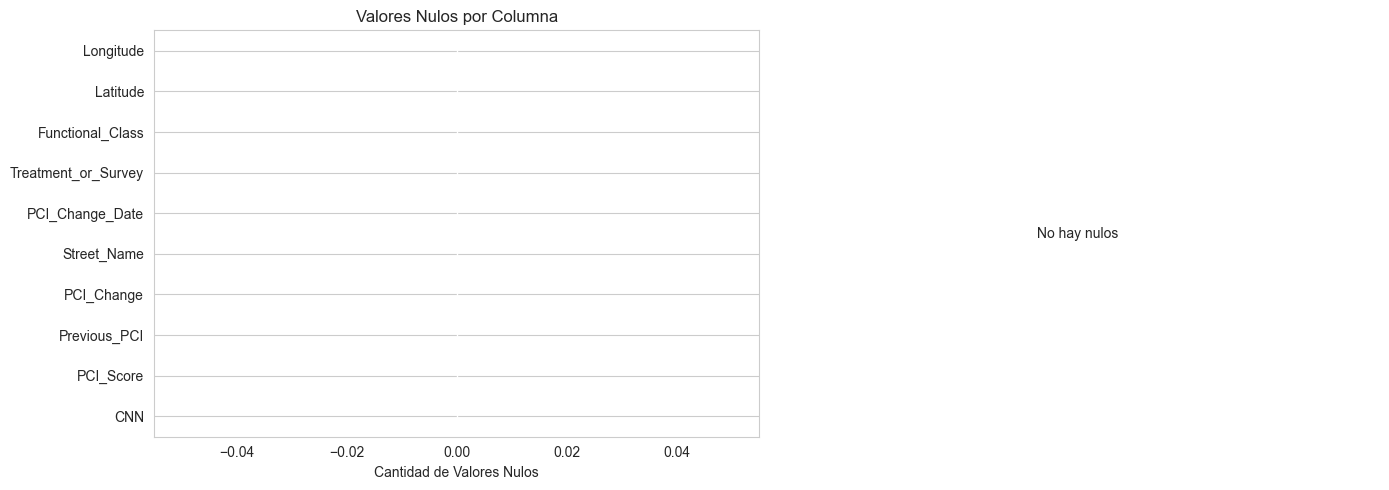

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
null_counts = df.isnull().sum().sort_values(ascending=False)
colors = ['red' if x > 0 else 'green' for x in null_counts.values]
null_counts.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Valores Nulos por Columna')
axes[0].set_xlabel('Cantidad de Valores Nulos')
axes[0].grid(axis='x')

null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]
if not null_pct_nonzero.empty:
    null_pct_nonzero.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Porcentaje de Valores Nulos por Columna')
    axes[1].set_xlabel('Porcentaje (%)')
    axes[1].grid(axis='x')
else:
    axes[1].text(0.5, 0.5, 'No hay nulos', ha='center', va='center')
    axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## 5. Análisis estadístico de PCI_Score

In [65]:
print('Estadísticas de PCI_Score:')
print(df['PCI_Score'].describe())
print('\nValores clave:')
print(f"Mínimo: {df['PCI_Score'].min():.2f}")
print(f"Máximo: {df['PCI_Score'].max():.2f}")
print(f"Media: {df['PCI_Score'].mean():.2f}")
print(f"Mediana: {df['PCI_Score'].median():.2f}")
print(f"Desviación estándar: {df['PCI_Score'].std():.2f}")
print(f"Rango intercuartil: {(df['PCI_Score'].quantile(0.75) - df['PCI_Score'].quantile(0.25)):.2f}")

Estadísticas de PCI_Score:
count    203268.000000
mean         72.755574
std          18.906356
min           0.000000
25%          60.000000
50%          77.000000
75%          85.000000
max         100.000000
Name: PCI_Score, dtype: float64

Valores clave:
Mínimo: 0.00
Máximo: 100.00
Media: 72.76
Mediana: 77.00
Desviación estándar: 18.91
Rango intercuartil: 25.00


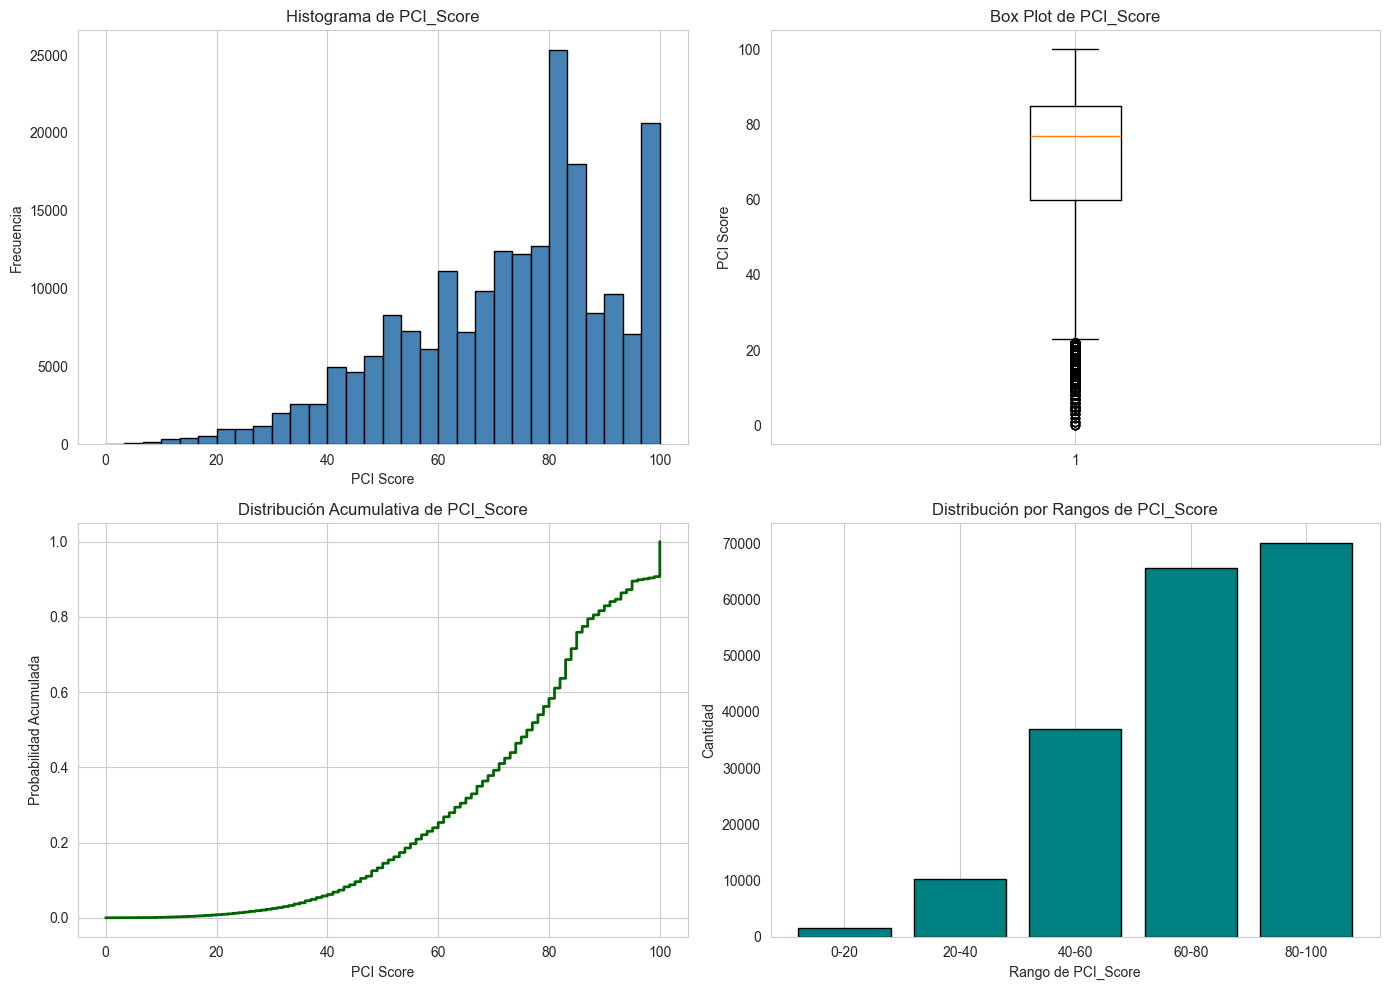


Distribución por rangos:
PCI_Score
0-20       1445
20-40     10281
40-60     36879
60-80     65573
80-100    70146
Name: count, dtype: int64
PCI_Score
0-20       0.71
20-40      5.06
40-60     18.14
60-80     32.26
80-100    34.51
Name: count, dtype: float64


In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['PCI_Score'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Histograma de PCI_Score')
axes[0, 0].set_xlabel('PCI Score')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y')

axes[0, 1].boxplot(df['PCI_Score'].dropna(), vert=True)
axes[0, 1].set_title('Box Plot de PCI_Score')
axes[0, 1].set_ylabel('PCI Score')
axes[0, 1].grid(axis='y')

sorted_pci = np.sort(df['PCI_Score'].dropna())
cumulative = np.arange(1, len(sorted_pci) + 1) / len(sorted_pci)
axes[1, 0].plot(sorted_pci, cumulative, linewidth=2, color='darkgreen')
axes[1, 0].set_title('Distribución Acumulativa de PCI_Score')
axes[1, 0].set_xlabel('PCI Score')
axes[1, 0].set_ylabel('Probabilidad Acumulada')
axes[1, 0].grid(True)

ranges = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
binned = pd.cut(df['PCI_Score'], bins=ranges, labels=labels, right=False)
binned_counts = binned.value_counts().sort_index()
axes[1, 1].bar(range(len(binned_counts)), binned_counts.values, color='teal', edgecolor='black')
axes[1, 1].set_xticks(range(len(binned_counts)))
axes[1, 1].set_xticklabels(binned_counts.index)
axes[1, 1].set_title('Distribución por Rangos de PCI_Score')
axes[1, 1].set_xlabel('Rango de PCI_Score')
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].grid(axis='y')

plt.tight_layout()
plt.show()
print('\nDistribución por rangos:')
print(binned_counts)
print((binned_counts / len(df) * 100).round(2))

## 6. Análisis de variables categóricas

In [67]:
for col in ['Treatment_or_Survey', 'Functional_Class']:
    print(f'\n=== {col} ===')
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({
        'Valor': counts.index,
        'Cantidad': counts.values,
        'Porcentaje (%)': pct.values.round(2)
    })
    print(summary.to_string(index=False))


=== Treatment_or_Survey ===
    Valor  Cantidad  Porcentaje (%)
   Survey    186584           91.79
Treatment     16684            8.21

=== Functional_Class ===
       Valor  Cantidad  Porcentaje (%)
 Residential    119409           58.74
    Arterial     55915           27.51
   Collector     21587           10.62
       Other      3691            1.82
Intersection      2666            1.31


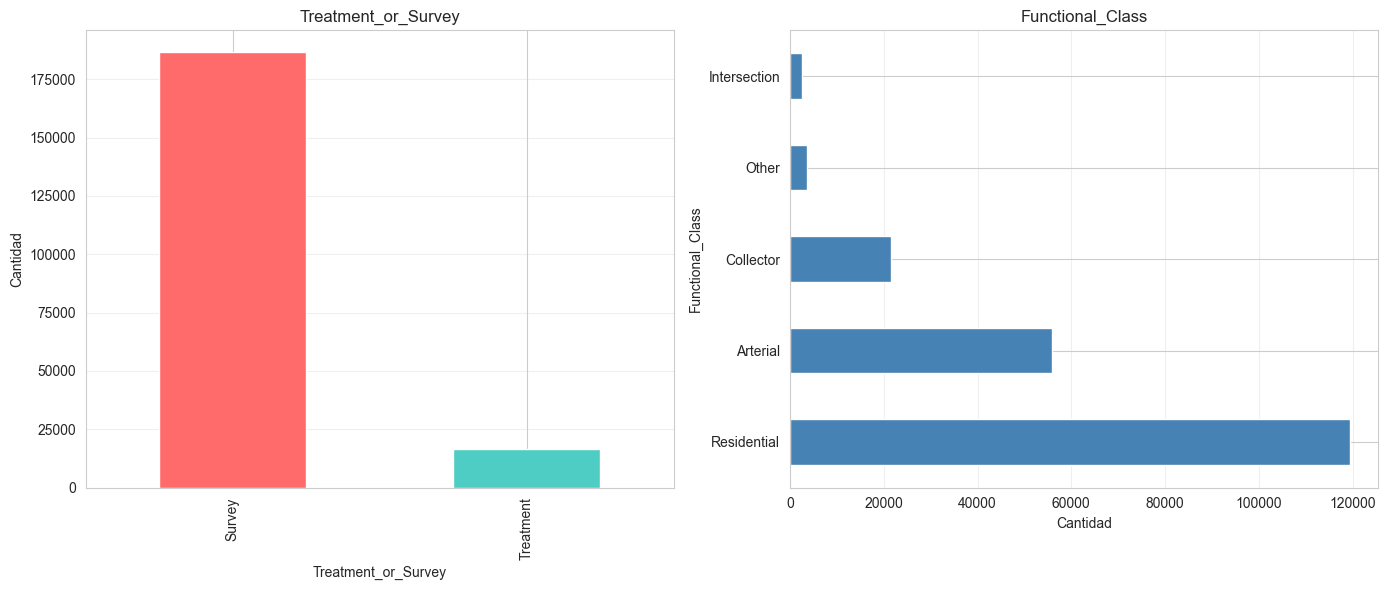

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if 'Treatment_or_Survey' in df.columns:
    df['Treatment_or_Survey'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
    axes[0].set_title('Treatment_or_Survey')
    axes[0].set_ylabel('Cantidad')
    axes[0].grid(axis='y', alpha=0.3)

if 'Functional_Class' in df.columns:
    df['Functional_Class'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Functional_Class')
    axes[1].set_xlabel('Cantidad')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análisis temporal

In [69]:
df['PCI_Change_Date'] = pd.to_datetime(df['PCI_Change_Date'], errors='coerce')
df['Year'] = df['PCI_Change_Date'].dt.year
df['Month'] = df['PCI_Change_Date'].dt.month

print(f'Fecha mínima: {df["PCI_Change_Date"].min()}')
print(f'Fecha máxima: {df["PCI_Change_Date"].max()}')
print(f'Registros con fechas válidas: {df["Year"].notna().sum():,}')
print(f'Registros con fechas inválidas: {df["Year"].isna().sum():,}')

yearly_counts = df[df['Year'].notna()]['Year'].value_counts().sort_index()
print('\nRegistros por año:')
print(yearly_counts)

Fecha mínima: 2005-01-26 02:11:29
Fecha máxima: 2026-05-19 08:28:06
Registros con fechas válidas: 203,268
Registros con fechas inválidas: 0

Registros por año:
Year
2005     6519
2006      364
2007     7021
2008     8229
2009     6868
2010     5405
2011      843
2012     7924
2013     8552
2014    16250
2015    15508
2016     4747
2017    12409
2018    12368
2019    12481
2020    12828
2021    12485
2022    12684
2023    13402
2024    13249
2025    12896
2026      236
Name: count, dtype: int64


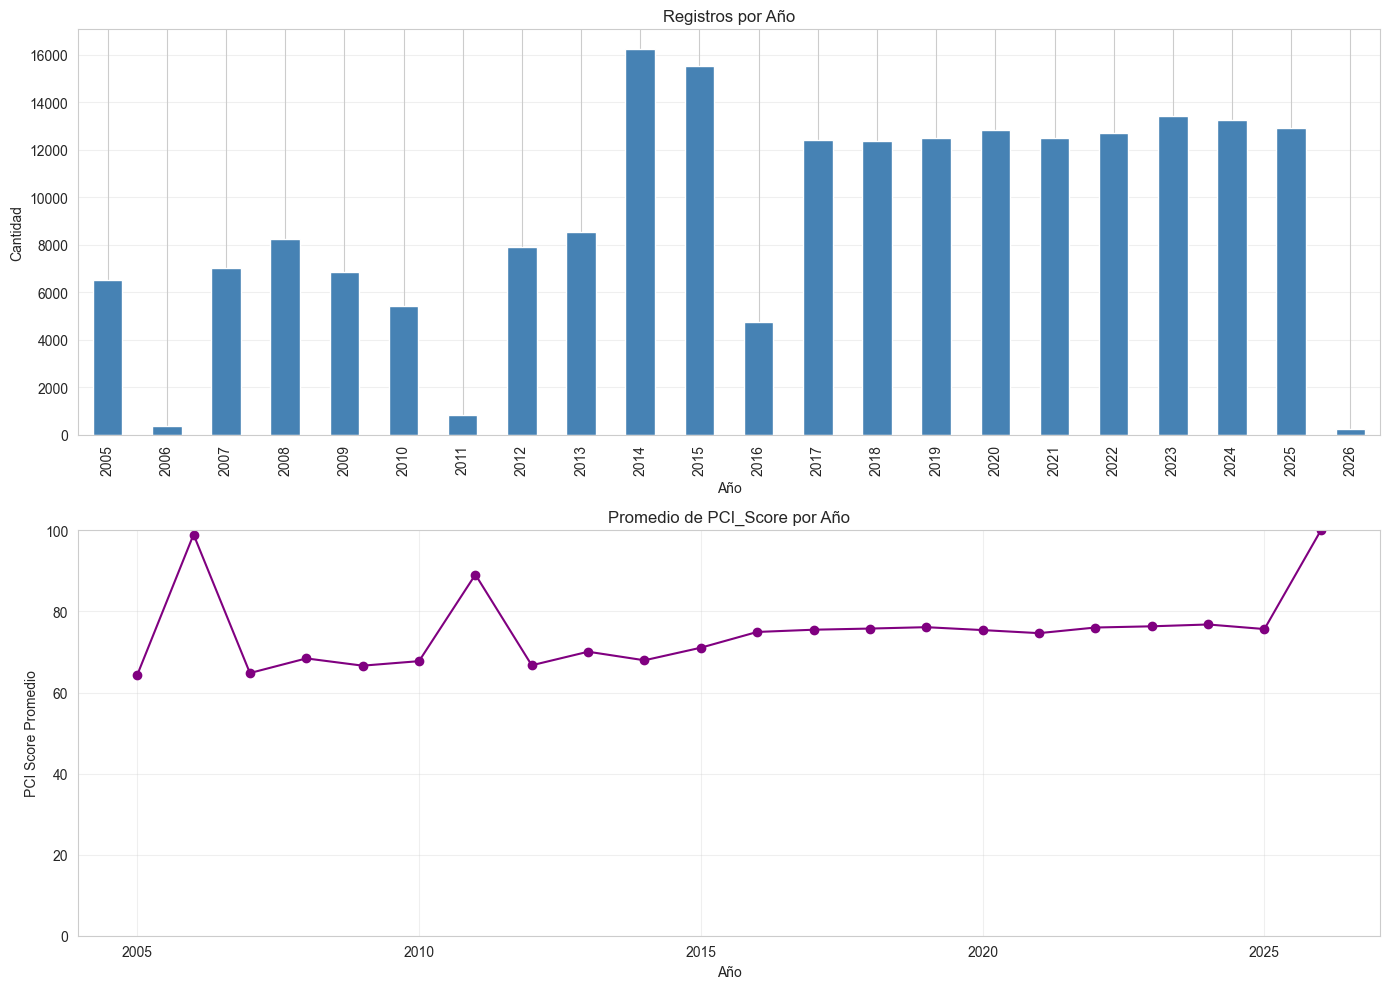

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
yearly_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Registros por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')
axes[0].grid(axis='y', alpha=0.3)

avg_pci_yearly = df[df['Year'].notna()].groupby('Year')['PCI_Score'].mean()
avg_pci_yearly.plot(kind='line', ax=axes[1], marker='o', color='purple')
axes[1].set_title('Promedio de PCI_Score por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('PCI Score Promedio')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 8. Análisis geográfico

In [71]:
print('Coordenadas Latitude/Longitude:')
print(f"Latitude mínimo: {df['Latitude'].min():.6f}")
print(f"Latitude máximo: {df['Latitude'].max():.6f}")
print(f"Longitude mínimo: {df['Longitude'].min():.6f}")
print(f"Longitude máximo: {df['Longitude'].max():.6f}")

Coordenadas Latitude/Longitude:
Latitude mínimo: 37.707903
Latitude máximo: 37.822087
Longitude mínimo: -122.513581
Longitude máximo: -122.366569


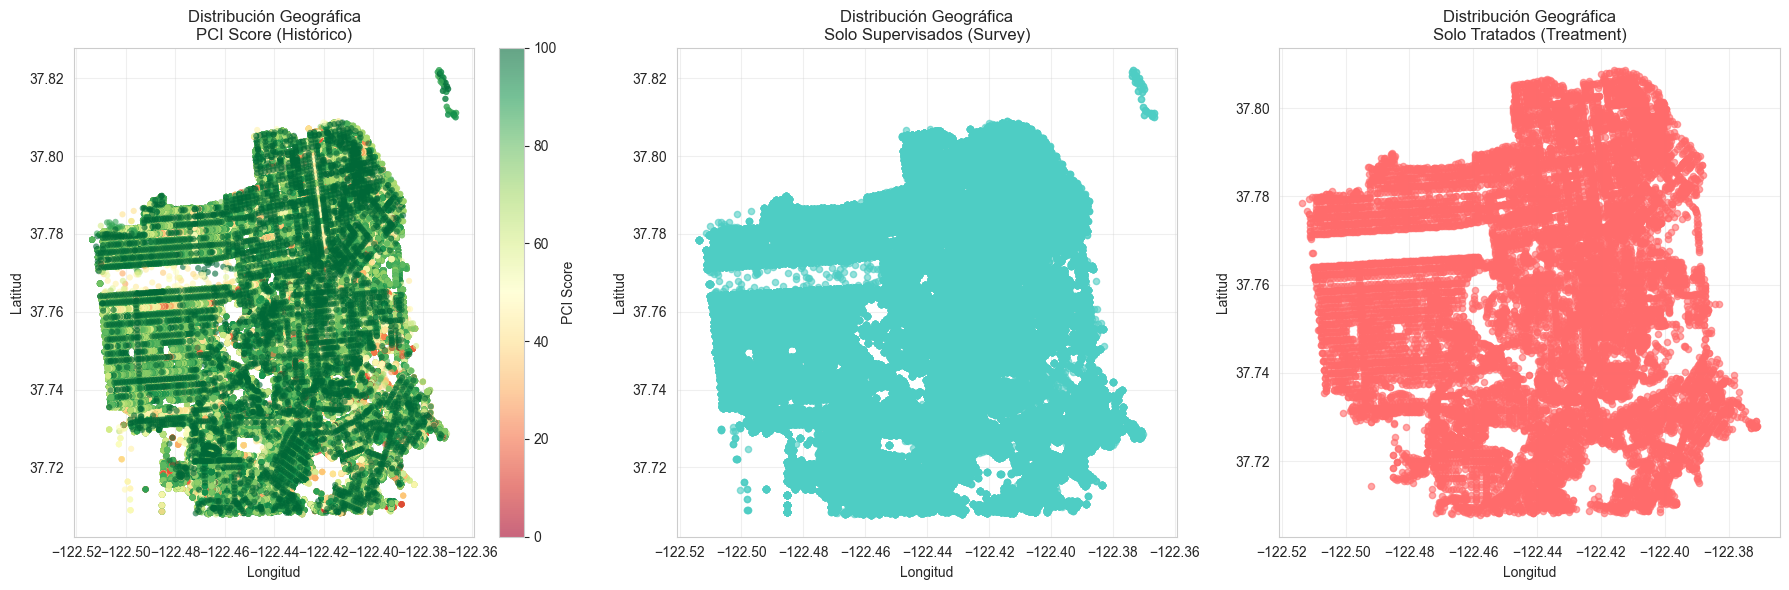

✓ Mapas geográficos generados (PCI, Supervisados y Tratados independientes)


In [72]:
import matplotlib.pyplot as plt

# Cambiamos a 1 fila y 3 columnas (ajustamos el ancho a 18)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Scatter plot con colores por PCI
scatter = axes[0].scatter(df['Longitude'], df['Latitude'], 
                          c=df['PCI_Score'], cmap='RdYlGn',
                          alpha=0.6, s=20, edgecolors='none')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].set_title('Distribución Geográfica\nPCI Score (Histórico)')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('PCI Score')
axes[0].grid(True, alpha=0.3)

# 2. Scatter plot SOLO para Supervisados (Survey)
mask_survey = df['Treatment_or_Survey'] == 'Survey'
axes[1].scatter(df[mask_survey]['Longitude'], df[mask_survey]['Latitude'],
                alpha=0.6, s=20, color='#4ECDC4', label='Survey')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].set_title('Distribución Geográfica\nSolo Supervisados (Survey)')
axes[1].grid(True, alpha=0.3)

# 3. Scatter plot SOLO para Tratados (Treatment)
mask_treatment = df['Treatment_or_Survey'] == 'Treatment'
axes[2].scatter(df[mask_treatment]['Longitude'], df[mask_treatment]['Latitude'],
                alpha=0.6, s=20, color='#FF6B6B', label='Treatment')
axes[2].set_xlabel('Longitud')
axes[2].set_ylabel('Latitud')
axes[2].set_title('Distribución Geográfica\nSolo Tratados (Treatment)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Mapas geográficos generados (PCI, Supervisados y Tratados independientes)')


## 9. Detección de duplicados

In [73]:
duplicated_cnn = df['CNN'].duplicated().sum()
duplicated_records = df.duplicated(subset=['CNN', 'PCI_Change_Date']).sum()
print(f'Duplicados en CNN: {duplicated_cnn}')
print(f'Duplicados exactos por CNN y PCI_Change_Date: {duplicated_records}')

Duplicados en CNN: 185089
Duplicados exactos por CNN y PCI_Change_Date: 0
